In [1]:
from Simulation.mpc import *
from Simulation.system_functions import PolymerCSTR
from utils.helpers import *

# Initializing The system

In [2]:
# First initiate the system
# Parameters
Ad = 2.142e17           # h^-1
Ed = 14897              # K
Ap = 3.816e10           # L/(molh)
Ep = 3557               # K
At = 4.50e12            # L/(molh)
Et = 843                # K
fi = 0.6                # Coefficient
m_delta_H_r = -6.99e4   # j/mol
hA = 1.05e6             # j/(Kh)
rhocp = 1506            # j/(Kh)
rhoccpc = 4043          # j/(Kh)
Mm = 104.14             # g/mol
system_params = np.array([Ad, Ed, Ap, Ep, At, Et, fi, m_delta_H_r, hA, rhocp, rhoccpc, Mm])

In [3]:
# Design Parameters
CIf = 0.5888    # mol/L
CMf = 8.6981    # mol/L
Qi = 108.       # L/h
Qs = 459.       # L/h
Tf = 330.       # K
Tcf = 295.      # K
V = 3000.       # L
Vc = 3312.4     # L

system_design_params = np.array([CIf, CMf, Qi, Qs, Tf, Tcf, V, Vc])

In [4]:
# Steady State Inputs
Qm_ss = 378.    # L/h
Qc_ss = 471.6   # L/h

system_steady_state_inputs = np.array([Qc_ss, Qm_ss])

In [5]:
# Sampling time of the system
delta_t = 0.5 # 30 mins

In [6]:
# Initiate the CSTR for steady state values
cstr = PolymerCSTR(system_params, system_design_params, system_steady_state_inputs, delta_t)
steady_states={"ss_inputs":cstr.ss_inputs,
               "y_ss":cstr.y_ss}

## Loading the system matrices, min max scaling, and min max of the states

In [7]:
dir_path = os.path.join(os.getcwd(), "Data")

In [8]:
# Defining the range of setpoints for data generation
setpoint_y = np.array([[2.8, 320.],
                       [5., 326.]])
u_min = np.array([71.6, 78])
u_max = np.array([870, 670])

system_data = load_and_prepare_system_data(steady_states=steady_states, setpoint_y=setpoint_y, u_min=u_min, u_max=u_max)

In [9]:
A_aug = system_data["A_aug"]
B_aug = system_data["B_aug"]
C_aug = system_data["C_aug"]

In [10]:
data_min = system_data["data_min"]
data_max = system_data["data_max"]

In [11]:
# min_max_states = system_data["min_max_states"]
# min_max_states = system_data["min_max_states"]
min_max_states = {'max_s': np.array([256.79686253, 256.01560603,  48.99447186, 144.79949103,
          2.82199733,   3.14014989,   2.78866348,   3.71691422,
          6.2029936 ]),
                  'min_s': np.array([ -272.28060121, -1112.33972595,   -76.63993491,  -608.60327886,
           -3.94399122,    -3.93115257,    -2.9532091 ,    -4.06547624,
          -28.25906582])}

In [12]:
y_sp_scaled_deviation = system_data["y_sp_scaled_deviation"]

In [13]:
b_min = system_data["b_min"]
b_max = system_data["b_max"]

In [14]:
min_max_dict = system_data["min_max_dict"]
min_max_dict["x_max"] = np.array([256.79686253, 256.01560603,  48.99447186, 144.79949103,
          2.82199733,   3.14014989,   2.78866348,   3.71691422,
          6.2029936 ])
min_max_dict["x_min"] = np.array([ -272.28060121, -1112.33972595,   -76.63993491,  -608.60327886,
           -3.94399122,    -3.93115257,    -2.9532091 ,    -4.06547624,
          -28.25906582])

In [15]:
# Observer Gain
poles = np.array(np.array([0.44619852, 0.33547649, 0.36380595, 0.70467118, 0.3562966,
                           0.42900673, 0.4228262 , 0.96916776, 0.91230187]))
L = compute_observer_gain(A_aug, C_aug, poles)

The system is observable.


C:\Users\HAMEDI\OneDrive - McMaster University\PythonProjects\RL_assisted_MPC_polymer\Simulation\mpc.py:124: UserWarning: Convergence was not reached after maxiter iterations.
You asked for a tolerance of 0.001, we got 0.9999999422182039.
  obs_gain_calc = signal.place_poles(A.T, C.T, desired_poles, method='KNV0')


## Initiating DQN

In [16]:
from DQN.dqn_agent import DQNAgent
import torch

In [17]:
PREDICT_GRID = list(range(8, 20))  # Hp candidates
CONTROL_GRID = list(range(3, 10))     # Hc candidates (will be filtered by Hc <= Hp)

In [18]:
HORIZON_RECIPES = build_horizon_recipes(PREDICT_GRID, CONTROL_GRID)
N_ACTIONS = len(HORIZON_RECIPES)

In [19]:
STATE_DIM = int(A_aug.shape[0]) + int(C_aug.shape[0]) + int(B_aug.shape[1])
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', DEVICE)
HIDDEN_LAYERS = [512, 512, 512, 512]
BUFFER_SIZE = 1000000
DECISION_INTERVAL = 5
INPUT_NUMBER = B_aug.shape[1]

Using device: cuda


In [20]:
dqn_agent = DQNAgent(
    state_dim=STATE_DIM,
    action_dim=N_ACTIONS,
    hidden_dim=HIDDEN_LAYERS,
    gamma=0.99,
    lr=1e-3,
    batch_size=128,
    buffer_size=BUFFER_SIZE,
    grad_clip_norm=10.0,
    double_dqn=True,
    target_update="soft",
    tau=0.01,
    hard_update_interval=10_000,
    target_combine="q1",
    activation="relu",
    use_layer_norm=False,
    dropout=0.0,
    device=DEVICE,
    eps_start=0.2,
    eps_end=0.01,
    eps_decay_rate=0.99995,
    eps_decay_mode="exp",
)

## Initiating TD3

In [21]:
from TD3Agent.agent import TD3Agent

In [22]:
set_points_number = int(C_aug.shape[0])
inputs_number = int(B_aug.shape[1])
STATE_DIM = int(A_aug.shape[0]) + set_points_number + inputs_number
ACTION_DIM = 3 # or Matrix A nad B (Change this to a more general format)
n_outputs = C_aug.shape[0]
a_coef, b_coef, c_coef = 1, 1, 1
ACTOR_LAYER_SIZES = [512, 512, 512, 512]
CRITIC_LAYER_SIZES = [512, 512, 512, 512]
BUFFER_CAPACITY = 1000000
ACTOR_LR = 1e-4
CRITIC_LR = 1e-4
SMOOTHING_STD = 0.1
NOISE_CLIP = 0.5
EXPLORATION_NOISE_STD = 0.2
GAMMA = 0.99
TAU = 0.005
MAX_ACTION = 1
POLICY_DELAY = 2
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BATCH_SIZE = 128
STD_START = 0.2
STD_END = 0.01
STD_DECAY_RATE = 0.99995
STD_DECAY_MODE = "exp"
ACTOR_FREEZE = 0

In [23]:
td3_agent = TD3Agent(
    state_dim=STATE_DIM,
    action_dim=ACTION_DIM,
    actor_hidden=ACTOR_LAYER_SIZES,
    critic_hidden=CRITIC_LAYER_SIZES,
    gamma=GAMMA,
    actor_lr=ACTOR_LR,
    critic_lr=CRITIC_LR,
    batch_size=BATCH_SIZE,
    policy_delay=POLICY_DELAY,
    target_policy_smoothing_noise_std=SMOOTHING_STD,
    noise_clip=NOISE_CLIP,
    max_action=MAX_ACTION,
    tau=TAU,
    std_start=STD_START,
    std_end=STD_END,
    std_decay_rate=STD_DECAY_RATE,
    std_decay_mode=STD_DECAY_MODE,
    buffer_size=BUFFER_CAPACITY,
    device=DEVICE,
    actor_freeze=ACTOR_FREEZE,
    )

## MPC initialization and setpoints

In [24]:
# MPC parameters
predict_h = 9
cont_h = 3
b1 = (b_min[0], b_max[0])
b2 = (b_min[1], b_max[1])
bnds = (b1, b2)*cont_h
cons = []
IC_opt = np.zeros(inputs_number*cont_h)
Q1_penalty = 5
Q2_penalty = 1
R1_penalty = 1
R2_penalty = 1
Q1_penalty_r, Q2_penalty_r = 12, 8
Q_penalty = np.array([[Q1_penalty, 0], [0, Q2_penalty]])
R_penalty = np.array([[R1_penalty, 0], [0, R2_penalty]])

In [25]:
MPC_obj = MpcSolver(A_aug, B_aug, C_aug,
                    Q1_penalty, Q2_penalty, R1_penalty, R2_penalty,
                    predict_h, cont_h)

In [26]:
y_sp_scenario = np.array([[4.5, 324],
                          [3.4, 321]])

# y_sp_scenario = np.concatenate((steady_states["y_ss"].reshape(1, -1), y_sp_scenario), axis=0)


y_sp_scenario = apply_min_max(y_sp_scenario, data_min[2:], data_max[2:]) - apply_min_max(steady_states["y_ss"], data_min[2:], data_max[2:])
n_tests = 200
set_points_len = 400
TEST_CYCLE = [False, False, False, False, False]
warm_start = 0

In [27]:
nominal_qs = 459
nominal_qi = 108
nominal_hA = 1.05e6
qi_change = 0.95
qs_change = 1.05
ha_change = 0.92

In [28]:
HIGH_COEF, LOW_COEF = np.array([1.05, 1.1, 1.1]), np.array([0.9, 0.9, 0.9])

## Applying on the system

In [29]:
def run_joint_dqn_td3(
        system, y_sp_scenario, n_tests, set_points_len, steady_states, min_max_dict, # system and setpoint info
        dqn_agent, td3_agent, # agnets
        A_aug, B_aug, C_aug, # Model matrices
        Q1_penalty, Q2_penalty, R1_penalty, R2_penalty, L, # MPC penalties and observer
        data_min, data_max, warm_start, test_cycle, # data min max and process cycle
        nominal_qi, nominal_qs, nominal_ha, # disturbances
        qi_change, qs_change, ha_change,    # disturbances
        h_recipes,  # list of (Hp, Hc)
        b_min, b_max,   # input boundaries
        high_coef, low_coef,    # matrices boundaries
        predict_h=9, cont_h=3,  # Nominal control and prediction horizons
        decision_interval=5 # how often DQN can change (Hp,Hc)
):
    """
    DQN chooses horizons (Hp,Hc). TD3 scales A,B via multipliers before each MPC solve.
    Both get the same state, the same reward.
    """

    # --- setpoints generation ---
    y_sp, nFE, sub_episodes_changes_dict, time_in_sub_episodes, test_train_dict, WARM_START, qi, qs, ha = \
        generate_setpoints_training_rl_gradually(
            y_sp_scenario, n_tests, set_points_len, warm_start, test_cycle,
            nominal_qi, nominal_qs, nominal_ha,
            qi_change, qs_change, ha_change
        )

    # inputs and outputs of the system dimensions
    n_inputs = B_aug.shape[1]
    n_outputs = C_aug.shape[0]
    n_states = A_aug.shape[0]

    # Scaled steady states inputs and outputs
    ss_scaled_inputs = apply_min_max(steady_states["ss_inputs"], data_min[:n_inputs], data_max[:n_inputs])
    y_ss_scaled = apply_min_max(steady_states["y_ss"], data_min[n_inputs:], data_max[n_inputs:])

    # Logging
    y_system = np.zeros((nFE + 1, n_outputs))
    y_system[0, :] = system.current_output
    u_mpc = np.zeros((nFE, n_inputs))
    rewards = np.zeros(nFE)
    avg_rewards = []
    yhat = np.zeros((n_outputs, nFE))
    xhatdhat = np.zeros((n_states, nFE + 1))
    xhatdhat[:, 0] = np.random.uniform(low=min_max_dict["x_min"], high=min_max_dict["x_max"])

    # multipliers and horizons logging
    horizon_trace = np.zeros((nFE, 2), dtype=int)
    multiplier_coefs_alpha = np.zeros((nFE + 1, 1))
    multiplier_coefs_delta = np.zeros((nFE + 1, n_inputs))

    # start MPC with nominal recipe
    last_a = None
    current_Hp, current_Hc = (predict_h, cont_h)
    MPC_obj = MpcSolver(A_aug, B_aug, C_aug,
                        Q1_penalty, Q2_penalty, R1_penalty, R2_penalty,
                        current_Hp, current_Hc)

    # Bounds and constraints
    b1 = (b_min[0], b_max[0])
    b2 = (b_min[1], b_max[1])
    cons = []

    # Helper to rebuild solver when Hc/Hp change
    def rebuild_mpc(Hp: int, Hc: int):
        nonlocal MPC_obj
        MPC_obj = MpcSolver(A_aug, B_aug, C_aug,
                            Q1_penalty, Q2_penalty, R1_penalty, R2_penalty,
                            Hp, Hc)

    # helper: map TD3 action
    def map_to_bounds(a, low, high):
        return low + ((a + 1.0) / 2.0) * (high - low)

    for i in range(nFE):
        # train/test phase
        if i in test_train_dict:
            test = test_train_dict[i]

        # Current scaled input & deviation
        scaled_current_input = apply_min_max(system.current_input, data_min[:n_inputs], data_max[:n_inputs])
        scaled_current_input_dev = scaled_current_input - ss_scaled_inputs

        # ---- RL state (both the agents will use same state) ----
        current_rl_state = apply_rl_scaled(min_max_dict, xhatdhat[:, i], y_sp[i, :], scaled_current_input_dev).astype(np.float32)

        # ----- DQN: choose (Hp,Hc) every decision_interval
        if (i % DECISION_INTERVAL == 0) or (last_a is None):
            a_idx = dqn_agent.take_action(current_rl_state.astype(np.float32), eval_mode=test)
            Hp, Hc = action_to_horizons(h_recipes, a_idx)
            # Rebuild MPC only if changed
            if (Hp, Hc) != (current_Hp, current_Hc):
                rebuild_mpc(Hp, Hc)
                current_Hp, current_Hc = Hp, Hc
            last_a = a_idx
        else:
            a_idx = last_a
            Hp, Hc = current_Hp, current_Hc

        horizon_trace[i] = (Hp, Hc)
        # Bounds and initial guess must match current Hc
        bnds  = (b1, b2) * Hc
        IC_opt = np.zeros(n_inputs * Hc)

        # ----- TD3: scale A,B before solving MPC
        # ---- TD3 action ----
        action = td3_agent.take_action(current_rl_state, explore=(not test))
        # Map to bounds
        action_mapped = map_to_bounds(action, low_coef, high_coef)
        alpha, delta = action_mapped[:-n_inputs], action_mapped[-n_inputs:]

        multiplier_coefs_alpha[i] = alpha
        multiplier_coefs_delta[i] = delta

        # ---- apply model scaling (from baselines each step) ----
        A_change = A_aug.copy()
        B_change = B_aug.copy()
        n_phys = n_states - n_outputs
        A_change[:n_phys, :n_phys] *= alpha
        B_change[:n_phys, :] *= delta.reshape(1, -1)

        MPC_obj.A = A_change
        MPC_obj.B = B_change

        # Solve MPC for current y_sp and model state x0_model
        sol = spo.minimize(
            lambda x: MPC_obj.mpc_opt_fun(x, y_sp[i, :], scaled_current_input_dev, xhatdhat[:, i]),
            IC_opt, bounds=bnds, constraints=cons
        )

        # Take first move (scaled deviation) and map to plant input
        u_mpc[i, :] = sol.x[:n_inputs] + ss_scaled_inputs
        u_plant = reverse_min_max(u_mpc[i, :], data_min[:n_inputs], data_max[:n_inputs])

        # delta u cost variables
        delta_u = u_mpc[i, :] - scaled_current_input

        # Apply to plant and step
        system.current_input = u_plant
        system.step()
        # disturbances
        system.hA = ha[i]
        system.Qs = qs[i]
        system.Qi = qi[i]

        # Record output
        y_system[i+1, :] = system.current_output

        # ----- Observer & model roll -----
        y_current_scaled = apply_min_max(y_system[i+1, :], data_min[n_inputs:], data_max[n_inputs:]) - y_ss_scaled
        y_prev_scaled = apply_min_max(y_system[i, :], data_min[n_inputs:], data_max[n_inputs:]) - y_ss_scaled

        # Calculate Delta y in deviation form
        delta_y = y_current_scaled - y_sp[i, :]

        # Calculate the next state in deviation form
        yhat[:, i] = np.dot(MPC_obj.C, xhatdhat[:, i])
        xhatdhat[:, i+1] = np.dot(MPC_obj.A, xhatdhat[:, i]) + np.dot(MPC_obj.B, (u_mpc[i, :] - ss_scaled_inputs)) + np.dot(L, (y_prev_scaled - yhat[:, i])).T

        # Reward Calculation (Both share the same reward)
        reward = - (Q1_penalty * delta_y[0] ** 2 + Q2_penalty * delta_y[1] ** 2 +
                    R1_penalty * delta_u[0] ** 2 + R2_penalty * delta_u[1] ** 2)

        # Record rewards
        rewards[i] = reward

        # next state for buffers
        next_u_dev = u_mpc[i, :] - ss_scaled_inputs
        next_rl_state = apply_rl_scaled(min_max_dict, xhatdhat[:, i+1], y_sp[i, :], next_u_dev)

        # Episode boundary (treat each setpoint block as an episode end)
        done = ((i + 1) % time_in_sub_episodes == 0) or (i == nFE - 1)

        # ----- store + train (skip during test slices)
        if not test:
            # DQN buffer
            dqn_agent.push(current_rl_state.astype(np.float32),
                       int(a_idx),
                       float(reward),
                       next_rl_state.astype(np.float32),
                       float(done))
            # TD3 buffer
            td3_agent.push(current_rl_state,
                       action.astype(np.float32),
                       float(reward),
                       next_rl_state,
                       float(done))

            if i >= WARM_START:
                _ = dqn_agent.train_step()
                _ = td3_agent.train_step()

        # diagnostics
        if i in sub_episodes_changes_dict:
            avg_rewards.append(np.mean(rewards[max(0, i - time_in_sub_episodes + 1): i + 1]))
            print(f"Sub_Episode {sub_episodes_changes_dict[i]} | avg. reward {avg_rewards[-1]:.4f} | "
                  f"Hp,Hc=({Hp},{Hc}) | alpha={multiplier_coefs_alpha[max(0, i - time_in_sub_episodes + 1): i+1, 0].mean():.4f} "
                  f"| delta={multiplier_coefs_delta[max(0, i - time_in_sub_episodes + 1): i+1, :].mean(axis=0):}")

    # reverse scaling for RL inputs
    u_rl = reverse_min_max(u_mpc, data_min[:n_inputs], data_max[:n_inputs])

    return (y_system, u_rl, avg_rewards, rewards, xhatdhat, nFE, time_in_sub_episodes,
            y_sp, yhat, qi, qs, ha, horizon_trace, multiplier_coefs_alpha, multiplier_coefs_delta)

In [30]:
cstr = PolymerCSTR(system_params, system_design_params, system_steady_state_inputs, delta_t)

In [31]:
(y_system, u_rl, avg_rewards, rewards, xhatdhat, nFE, time_in_sub_episodes,
 y_sp, yhat, qi, qs, ha, horizon_trace, mult_alpha, mult_delta) = run_joint_dqn_td3(
    system=cstr,
    y_sp_scenario=y_sp_scenario, n_tests=n_tests, set_points_len=set_points_len,
    steady_states=steady_states, min_max_dict=min_max_dict,
    dqn_agent=dqn_agent, td3_agent=td3_agent,
    A_aug=A_aug, B_aug=B_aug, C_aug=C_aug,
    Q1_penalty=Q1_penalty, Q2_penalty=Q2_penalty, R1_penalty=R1_penalty, R2_penalty=R2_penalty, L=L,
    data_min=data_min, data_max=data_max, warm_start=warm_start, test_cycle=TEST_CYCLE,
    nominal_qi=nominal_qi, nominal_qs=nominal_qs, nominal_ha=nominal_hA,
    qi_change=qi_change, qs_change=qs_change, ha_change=ha_change,
    h_recipes=HORIZON_RECIPES,
    b_min=b_min, b_max=b_max,
    high_coef=HIGH_COEF, low_coef=LOW_COEF,
    predict_h=predict_h, cont_h=cont_h,
    decision_interval=DECISION_INTERVAL
)

Sub_Episode 1 | avg. reward -3.2735 | Hp,Hc=(10,3) | alpha=0.9857 | delta=[1.00179895 0.98489567]
Sub_Episode 2 | avg. reward -3.0999 | Hp,Hc=(17,9) | alpha=0.9847 | delta=[0.97091825 0.97843971]
Sub_Episode 3 | avg. reward -3.0144 | Hp,Hc=(12,8) | alpha=1.0155 | delta=[1.00174732 1.01547216]
Sub_Episode 4 | avg. reward -3.6155 | Hp,Hc=(18,8) | alpha=1.0080 | delta=[0.9656628  1.03305846]
Sub_Episode 5 | avg. reward -4.0190 | Hp,Hc=(12,8) | alpha=1.0005 | delta=[0.93800768 1.03103485]
Sub_Episode 6 | avg. reward -3.4196 | Hp,Hc=(13,5) | alpha=0.9972 | delta=[0.9405572  1.03747951]
Sub_Episode 7 | avg. reward -3.5793 | Hp,Hc=(15,9) | alpha=0.9783 | delta=[0.94581857 1.03792253]
Sub_Episode 8 | avg. reward -3.1551 | Hp,Hc=(10,8) | alpha=0.9684 | delta=[1.01782205 1.04836651]
Sub_Episode 9 | avg. reward -3.0805 | Hp,Hc=(12,6) | alpha=0.9680 | delta=[1.0378914  1.06246722]
Sub_Episode 10 | avg. reward -2.9348 | Hp,Hc=(10,8) | alpha=0.9563 | delta=[1.04788994 1.06022089]
Sub_Episode 11 | av

In [32]:
import numpy as np
import matplotlib.pyplot as plt

def plot_rl_results_td3(
    y_sp,                # scaled-deviation setpoints, shape [nFE, ny]
    steady_states,       # {"y_ss": ...}
    nFE,                 # steps
    delta_t,             # hours/step
    time_in_sub_episodes,# block length (steps)
    y_mpc,               # ORIGINAL units, shape [nFE+1, ny]   (y_system)
    u_mpc,               # ORIGINAL units, shape [nFE, nu]     (u_rl)
    avg_rewards,         # list/array
    data_min, data_max,  # scaling arrays
    # Optional extras
    horizon_trace=None,                 # [nFE, 2] (Hp, Hc)
    coef_alpha=None,                    # [nFE] or [nFE+1, 1] : α_t (A-scale)
    coef_delta=None,                    # [nFE, nu] or [nFE+1, nu] : δ_t per input (B-scale)
    high_coef=None, low_coef=None,      # arrays like [α, δ1, δ2, ...]
    recipe_counts=False
):
    """
    Adds coefficient multiplier plots (alpha for A, delta_j for B_j) with LOW/HIGH bounds.
    Notes:
      - We align multipliers with the *input timeline* (length nFE), so we slice [:nFE].
      - Pass 'y_system' as y_mpc and 'u_rl' as u_mpc (original units).
      - If coef_* have length nFE+1 (allocated that way during rollout), we'll ignore the last row.
    """

    ny = y_mpc.shape[1]
    nu = u_mpc.shape[1]

    # ----- Unscale setpoints back to original units -----
    y_ss = apply_min_max(steady_states["y_ss"], data_min[2:], data_max[2:])
    y_sp_full = reverse_min_max(y_sp + y_ss, data_min[2:], data_max[2:]).T  # [ny, nFE]

    # ----- Time axes -----
    time_full   = np.linspace(0, nFE * delta_t, nFE + 1)                 # outputs (nFE+1)
    time_full_u = np.linspace(0, (nFE-1) * delta_t, nFE)                 # inputs (nFE)
    s0 = nFE - time_in_sub_episodes
    time_block   = np.linspace(0, time_in_sub_episodes * delta_t, time_in_sub_episodes + 1)
    time_block_u = np.linspace(0, (time_in_sub_episodes-1) * delta_t, time_in_sub_episodes)

    # =========================
    # 1) Outputs vs Setpoints (full)
    # =========================
    plt.figure(figsize=(10, 8))
    plt.subplot(2,1,1)
    plt.plot(time_full, y_mpc[:, 0], lw=2, label=r'$\mathbf{RL}$')
    plt.step(time_full[:-1], y_sp_full[0, :], where='post', linestyle='--', lw=2, label=r'$\mathbf{Setpoint}$')
    plt.ylabel(r'$\mathbf{\eta}$ (L/g)', fontsize=18); plt.grid(True); plt.legend(loc='best', fontsize=14)
    plt.tick_params(axis='both', labelsize=14)

    if ny >= 2:
        plt.subplot(2,1,2)
        plt.plot(time_full, y_mpc[:, 1], lw=2, label=r'$\mathbf{RL}$')
        plt.step(time_full[:-1], y_sp_full[1, :], where='post', linestyle='--', lw=2, label=r'$\mathbf{Setpoint}$')
        plt.ylabel(r'$\mathbf{T}$ (K)', fontsize=18); plt.xlabel(r'$\mathbf{Time}$ (hour)', fontsize=18)
        plt.grid(True); plt.legend(loc='best', fontsize=14); plt.tick_params(axis='both', labelsize=14)
    plt.tight_layout(); plt.show()

    # =========================
    # 2) Outputs vs Setpoints (last block)
    # =========================
    plt.figure(figsize=(10, 8))
    plt.subplot(2,1,1)
    plt.plot(time_block, y_mpc[s0:, 0], lw=2, label=r'$\mathbf{RL}$')
    plt.step(time_block[:-1], y_sp_full[0, s0:], where='post', linestyle='--', lw=2, label=r'$\mathbf{Setpoint}$')
    plt.ylabel(r'$\mathbf{\eta}$ (L/g)', fontsize=18); plt.grid(True); plt.legend(loc='best', fontsize=14)
    plt.tick_params(axis='both', labelsize=14)

    if ny >= 2:
        plt.subplot(2,1,2)
        plt.plot(time_block, y_mpc[s0:, 1], lw=2, label=r'$\mathbf{RL}$')
        plt.step(time_block[:-1], y_sp_full[1, s0:], where='post', linestyle='--', lw=2, label=r'$\mathbf{Setpoint}$')
        plt.ylabel(r'$\mathbf{T}$ (K)', fontsize=18); plt.xlabel(r'$\mathbf{Time}$ (hour)', fontsize=18)
        plt.grid(True); plt.legend(loc='best', fontsize=14); plt.tick_params(axis='both', labelsize=14)
    plt.tight_layout(); plt.show()

    # =========================
    # 3) Inputs (Qc, Qm, ...)
    # =========================
    plt.figure(figsize=(10, 8))
    for j in range(nu):
        plt.subplot(nu, 1, j+1)
        plt.step(time_full_u, u_mpc[:, j], where='post', lw=2, label=fr'$\mathbf{{u_{j+1}}}$')
        if j == nu-1:
            plt.xlabel(r'$\mathbf{Time}$ (hour)', fontsize=18)
        plt.ylabel(fr'$u_{j+1}$', fontsize=16)
        plt.grid(True); plt.legend(loc='best', fontsize=14)
        plt.tick_params(axis='both', labelsize=14)
    plt.tight_layout(); plt.show()

    # =========================
    # 4) Avg reward per block
    # =========================
    if len(avg_rewards) > 0:
        plt.figure(figsize=(10, 6))
        plt.plot(np.arange(1, len(avg_rewards) + 1), avg_rewards, 'o-', lw=2, label='Reward per Episode')
        plt.ylabel(r'Avg. Reward', fontsize=16, fontweight='bold')
        plt.xlabel(r'Episode #', fontsize=16, fontweight='bold')
        plt.grid(True, which='both', linestyle='--', linewidth=0.5)
        plt.legend(loc='best', fontsize=14)
        plt.tight_layout(); plt.show()

    # =========================
    # 5) Horizons (Hp, Hc) over time (optional)
    # =========================
    if horizon_trace is not None:
        Hp = horizon_trace[:, 0].astype(int)
        Hc = horizon_trace[:, 1].astype(int)

        plt.figure(figsize=(10, 7))
        plt.subplot(2,1,1)
        plt.step(time_full_u, Hp, where='post', lw=2, label='Hp')
        plt.ylabel('Prediction Horizon (steps)', fontsize=16); plt.grid(True); plt.legend(fontsize=14)
        plt.tick_params(axis='both', labelsize=14)

        plt.subplot(2,1,2)
        plt.step(time_full_u, Hc, where='post', lw=2, label='Hc')
        plt.ylabel('Control Horizon (steps)', fontsize=16); plt.xlabel('Time (hour)', fontsize=16)
        plt.grid(True); plt.legend(fontsize=14); plt.tick_params(axis='both', labelsize=14)
        plt.tight_layout(); plt.show()

        # last block
        plt.figure(figsize=(10, 7))
        plt.subplot(2,1,1)
        plt.step(time_block_u, Hp[s0:], where='post', lw=2, label='Hp')
        plt.ylabel('Prediction Horizon (steps)', fontsize=16); plt.grid(True); plt.legend(fontsize=14)
        plt.tick_params(axis='both', labelsize=14)

        plt.subplot(2,1,2)
        plt.step(time_block_u, Hc[s0:], where='post', lw=2, label='Hc')
        plt.ylabel('Control Horizon (steps)', fontsize=16); plt.xlabel('Time (hour)', fontsize=16)
        plt.grid(True); plt.legend(fontsize=14); plt.tick_params(axis='both', labelsize=14)
        plt.tight_layout(); plt.show()

        if recipe_counts:
            import collections
            counts = collections.Counter(list(zip(Hp, Hc)))
            pairs, freqs = zip(*sorted(counts.items(), key=lambda x: (-x[1], x[0])))
            labels = [f"Hp={p[0]}, Hc={p[1]}" for p in pairs]
            plt.figure(figsize=(10, 5))
            plt.bar(np.arange(len(freqs))[:20], freqs[:20])
            plt.xticks(np.arange(len(freqs))[:20], labels[:20], rotation=45, ha='right')
            plt.ylabel('Count'); plt.title('Horizon Pair Usage'); plt.grid(axis='y', linestyle='--', alpha=0.5)
            plt.tight_layout(); plt.show()

    # =========================
    # 6) Coefficient multipliers (α for A, δ_j for B)
    # =========================
    if coef_alpha is not None or coef_delta is not None:
        # slice to nFE
        if coef_alpha is not None:
            alpha = np.asarray(coef_alpha).reshape(-1)
            alpha = alpha[:nFE]  # align with input timeline
        else:
            alpha = None

        if coef_delta is not None:
            delta = np.asarray(coef_delta)
            if delta.shape[0] > nFE:
                delta = delta[:nFE, :]
        else:
            delta = None

        # bounds (if provided)
        have_bounds = (high_coef is not None) and (low_coef is not None)
        if have_bounds:
            high_coef = np.asarray(high_coef).reshape(-1)
            low_coef  = np.asarray(low_coef).reshape(-1)
            # Expect length 1+nu: [α, δ1..δnu]
            assert (high_coef.size == low_coef.size) and ((high_coef.size == 1 + nu) or (high_coef.size == 1 and delta is None)), \
                "high/low bounds must be shape [1+nu] (α plus per-input δ)."

        # --- full timeline ---
        rows = 1 + (delta.shape[1] if delta is not None else 0)
        plt.figure(figsize=(10, max(6, 2.5*rows)))

        r = 1
        if alpha is not None:
            plt.subplot(rows, 1, r)
            if have_bounds:
                plt.fill_between(time_full_u,
                                 low_coef[0], high_coef[0],
                                 alpha=0.15, step='post', label='α bounds')
                plt.hlines([low_coef[0], high_coef[0]], time_full_u[0], time_full_u[-1],
                           linestyles='--', linewidth=1.0)
            plt.step(time_full_u, alpha, where='post', lw=2, label='α (A-scale)')
            plt.ylabel(r'$\alpha$', fontsize=16)
            plt.grid(True); plt.legend(loc='best', fontsize=12)
            plt.tick_params(axis='both', labelsize=13)
            r += 1

        if delta is not None:
            for j in range(delta.shape[1]):
                plt.subplot(rows, 1, r)
                if have_bounds and high_coef.size >= 1+nu:
                    lo, hi = low_coef[1+j], high_coef[1+j]
                    plt.fill_between(time_full_u, lo, hi, alpha=0.15, step='post', label=f'δ{j+1} bounds')
                    plt.hlines([lo, hi], time_full_u[0], time_full_u[-1], linestyles='--', linewidth=1.0)
                plt.step(time_full_u, delta[:, j], where='post', lw=2, label=f'δ{j+1} (B col {j+1})')
                plt.ylabel(fr'$\delta_{j+1}$', fontsize=16)
                if j == delta.shape[1]-1:
                    plt.xlabel('Time (hour)', fontsize=16)
                plt.grid(True); plt.legend(loc='best', fontsize=12)
                plt.tick_params(axis='both', labelsize=13)
                r += 1

        plt.tight_layout(); plt.show()

        # --- last block ---
        if time_in_sub_episodes > 0:
            plt.figure(figsize=(10, max(6, 2.5*rows)))
            r = 1
            if alpha is not None:
                plt.subplot(rows, 1, r)
                if have_bounds:
                    plt.fill_between(time_block_u, low_coef[0], high_coef[0], alpha=0.15, step='post', label='α bounds')
                    plt.hlines([low_coef[0], high_coef[0]], time_block_u[0], time_block_u[-1],
                               linestyles='--', linewidth=1.0)
                plt.step(time_block_u, alpha[s0:], where='post', lw=2, label='α (A-scale)')
                plt.ylabel(r'$\alpha$', fontsize=16)
                plt.grid(True); plt.legend(loc='best', fontsize=12)
                plt.tick_params(axis='both', labelsize=13)
                r += 1

            if delta is not None:
                for j in range(delta.shape[1]):
                    plt.subplot(rows, 1, r)
                    if have_bounds and high_coef.size >= 1+nu:
                        lo, hi = low_coef[1+j], high_coef[1+j]
                        plt.fill_between(time_block_u, lo, hi, alpha=0.15, step='post', label=f'δ{j+1} bounds')
                        plt.hlines([lo, hi], time_block_u[0], time_block_u[-1], linestyles='--', linewidth=1.0)
                    plt.step(time_block_u, delta[s0:, j], where='post', lw=2, label=f'δ{j+1} (B col {j+1})')
                    plt.ylabel(fr'$\delta_{j+1}$', fontsize=16)
                    if j == delta.shape[1]-1:
                        plt.xlabel('Time (hour)', fontsize=16)
                    plt.grid(True); plt.legend(loc='best', fontsize=12)
                    plt.tick_params(axis='both', labelsize=13)
                    r += 1

            plt.tight_layout(); plt.show()

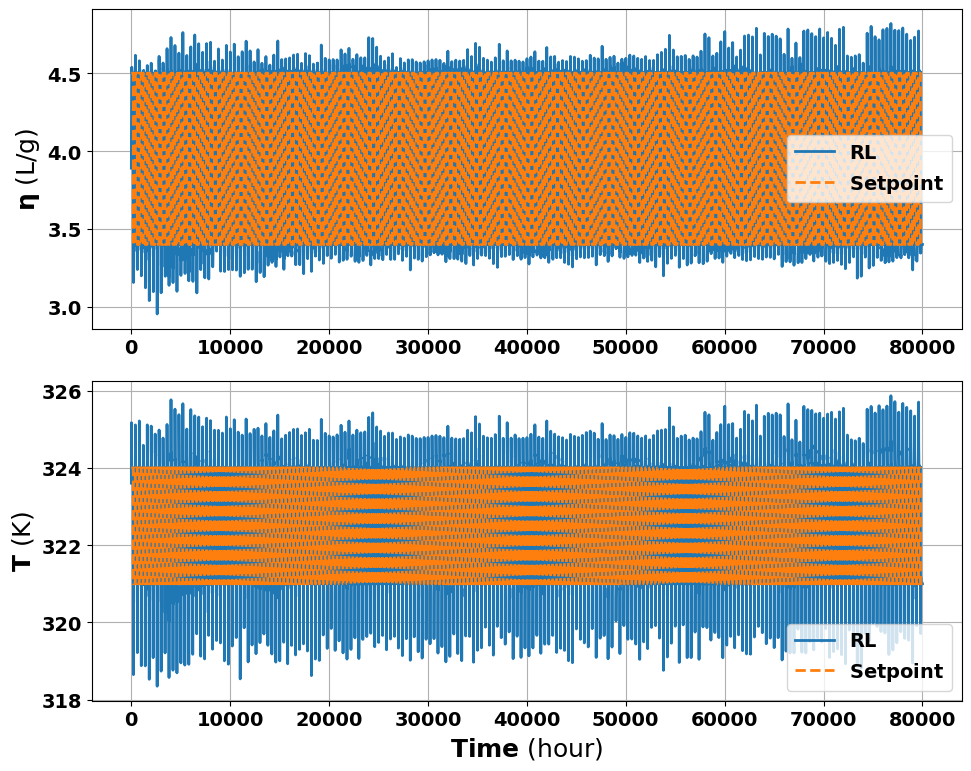

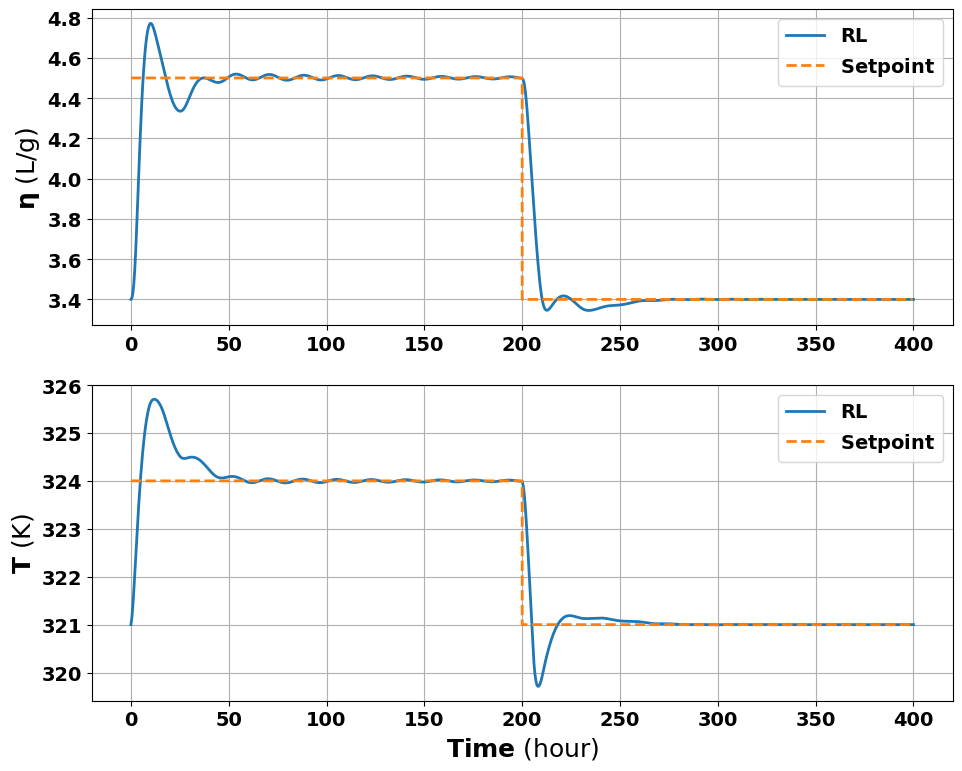

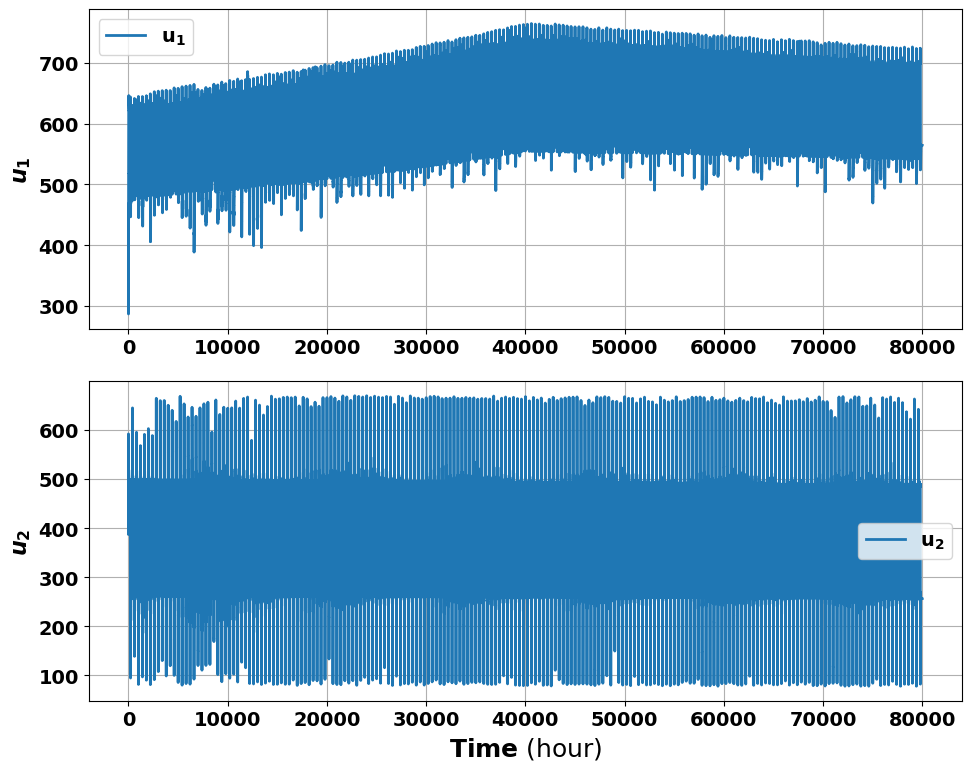

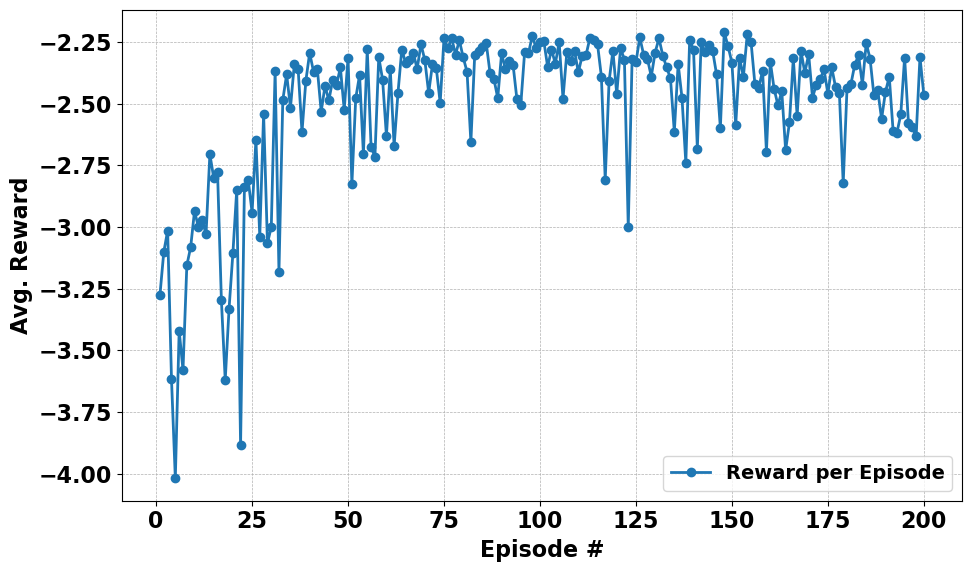

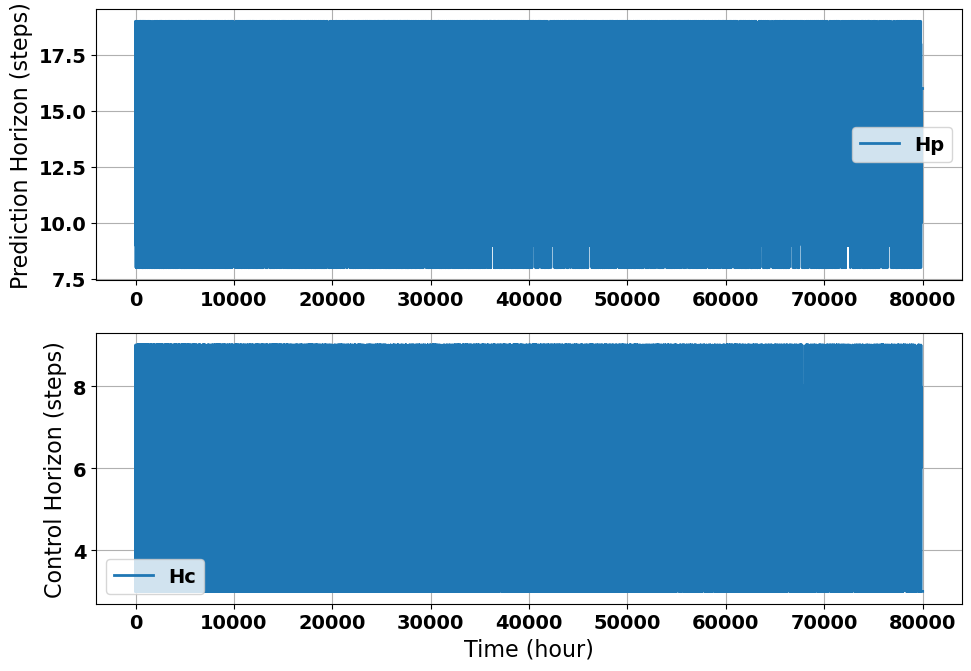

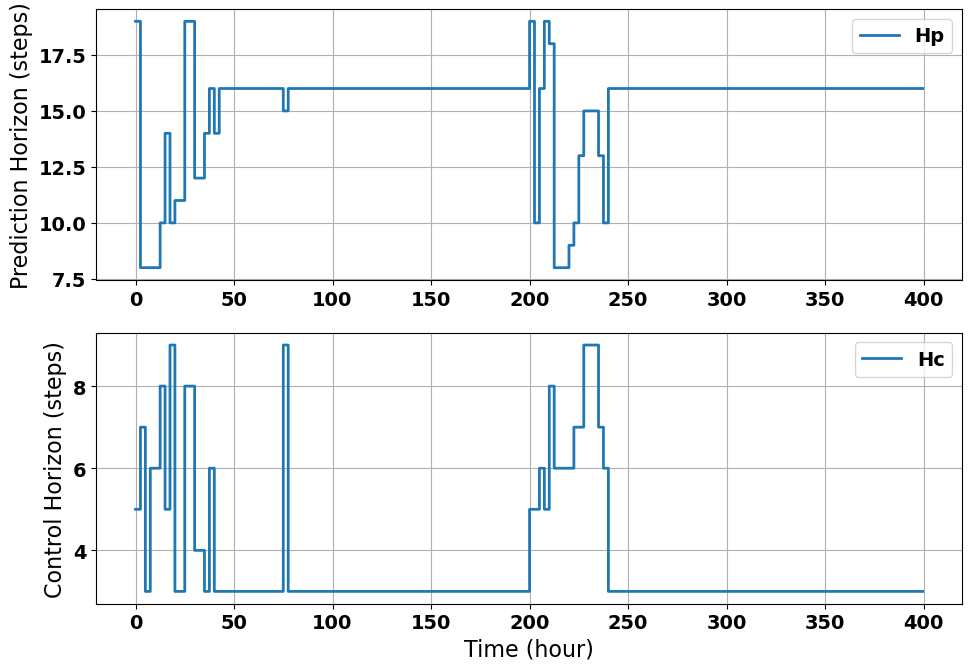

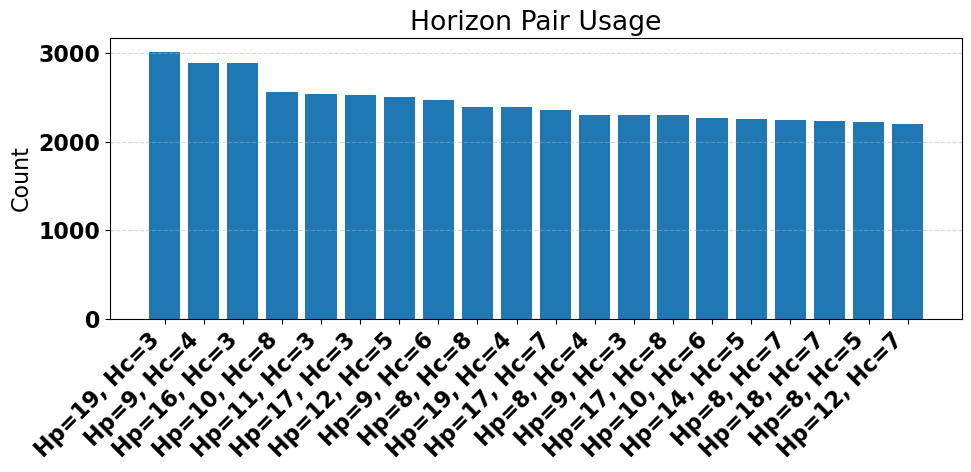

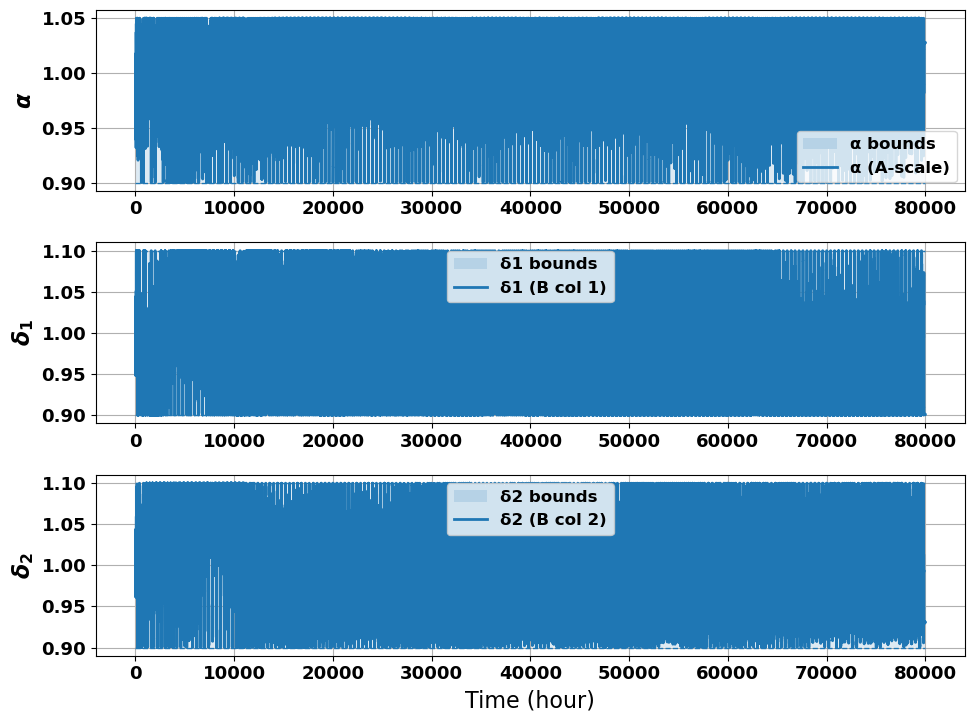

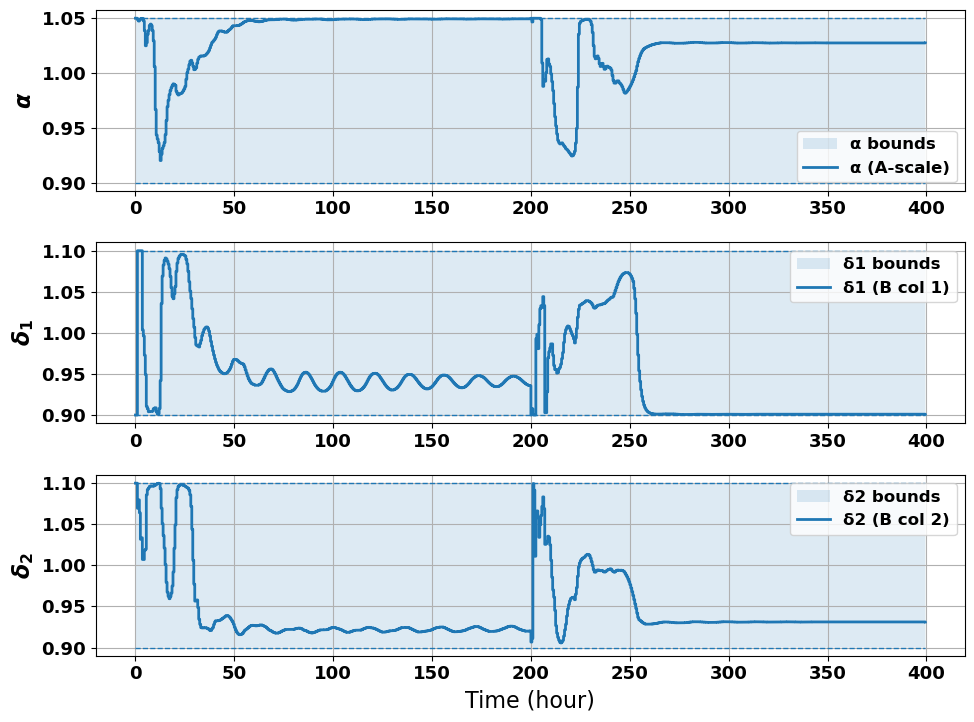

In [33]:
plot_rl_results_td3(
    y_sp=y_sp, steady_states=steady_states,
    nFE=nFE, delta_t=delta_t, time_in_sub_episodes=time_in_sub_episodes,
    y_mpc=y_system, u_mpc=u_rl, avg_rewards=avg_rewards,
    data_min=data_min, data_max=data_max,
    coef_alpha=mult_alpha[:, 0],     # from your run loop
    coef_delta=mult_delta[:, :],     # shape [nFE(+1), nu]
    high_coef=HIGH_COEF, low_coef=LOW_COEF,
    horizon_trace=horizon_trace,    # (nFE, 2)
    recipe_counts=True              # turn on histogram (optional)
)

In [35]:
def compare_mpc_rl_disturbance(y_rl, y_mpc, y_sp, avg_rewards_rl, avg_rewards_mpc, time_in_sub_episodes, delta_t):

    y_ss = apply_min_max(steady_states["y_ss"], data_min[2:], data_max[2:])
    y_sp = (y_sp + y_ss)
    y_sp = (reverse_min_max(y_sp, data_min[2:], data_max[2:]))

    # --- Plot the "last portion" (time_in_sub_episodes) ---
    # Convert those steps to their own time axis
    time_plot_sub = np.linspace(0, time_in_sub_episodes * delta_t, time_in_sub_episodes)
    s0 = -800

        # --- Global presentation style ---
    plt.rcParams.update({
        "font.size": 16,
        "axes.labelsize": 20,
        "axes.labelweight": "bold",
        "axes.titlesize": 22,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "mathtext.default": "regular"
    })
    LW, MS = 3.0, 6

    def _style(ax, xlabel=None, ylabel=None):
        if ylabel is not None:
            ax.set_ylabel(ylabel, fontsize=20, fontweight='bold')
        if xlabel is not None:
            ax.set_xlabel(xlabel, fontsize=20, fontweight='bold')
        ax.grid(True, which='both', linestyle='--', linewidth=0.8, alpha=0.7)
        ax.tick_params(axis='both', labelsize=16)
        ax.margins(x=0.01)

    # =========================
    # 1) Last block: y[:,0] and y[:,1]
    # =========================
    fig, axs = plt.subplots(2, 1, figsize=(11, 9), sharex=True)

    # Top subplot: CV1
    axs[0].plot(time_plot_sub, y_rl[s0:, 0], lw=LW)
    axs[0].plot(time_plot_sub, y_mpc[s0:, 0], linestyle='--', lw=LW)
    # Setpoint as a step (post) with same x-sampling
    axs[0].step(time_plot_sub, y_sp[s0:, 0], where='post', linestyle='--', lw=LW)
    _style(axs[0], ylabel=r'$\mathbf{\eta}$ (L/g)')

    # Bottom subplot: CV2
    axs[1].plot(time_plot_sub, y_rl[s0:, 1], lw=LW)
    axs[1].plot(time_plot_sub, y_mpc[s0:, 1], linestyle='--', lw=LW)
    axs[1].step(time_plot_sub, y_sp[s0:, 1], where='post', linestyle='--', lw=LW)
    _style(axs[1], xlabel=r'$\mathbf{Time}$ (hour)', ylabel=r'$\mathbf{T}$ (K)')

    fig.tight_layout()
    plt.show()

    # =========================
    # 2) Average rewards per episode
    # =========================
    plt.figure(figsize=(11, 9))
    x_rl = np.arange(1, len(avg_rewards_rl) + 1)
    x_mpc = np.arange(1, len(avg_rewards_mpc) + 1)

    plt.plot(x_rl, avg_rewards_rl, 'o-', lw=LW, markersize=MS)
    plt.plot(x_mpc, avg_rewards_mpc, 'o--', lw=LW, markersize=MS)
    plt.ylabel(r'Avg. Reward', fontsize=20, fontweight='bold')
    plt.xlabel(r'Episode #', fontsize=20, fontweight='bold')
    plt.grid(True, which='both', linestyle='--', linewidth=0.8, alpha=0.7)
    plt.tight_layout()
    plt.show()

In [36]:
save_path = os.path.join(dir_path, "mpc_results_disturbance.pickle")
with open(save_path, 'rb') as file:
    mpc_results = pickle.load(file)
y_mpc = mpc_results["y_mpc"]
u_mpc = mpc_results["u_mpc"]
xhatdhat_mpc = mpc_results["xhatdhat"]
avg_rewards_mpc = mpc_results["avg_rewards"]

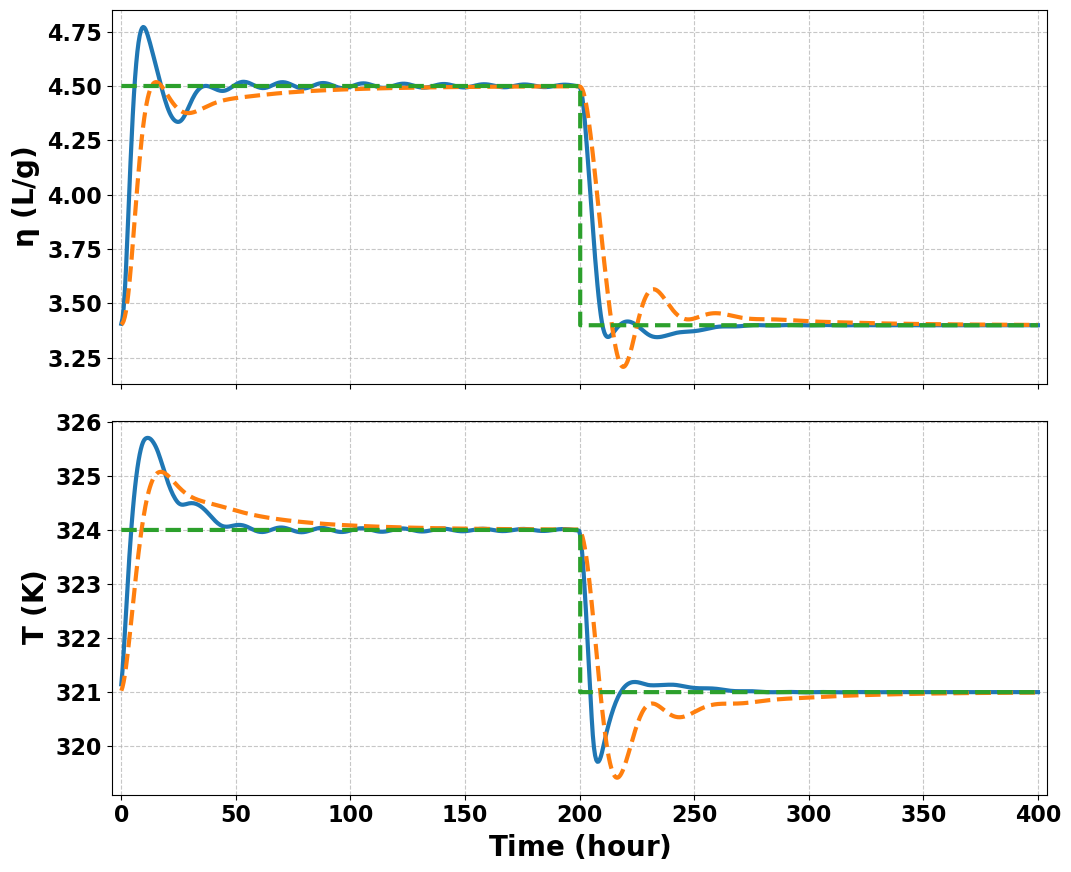

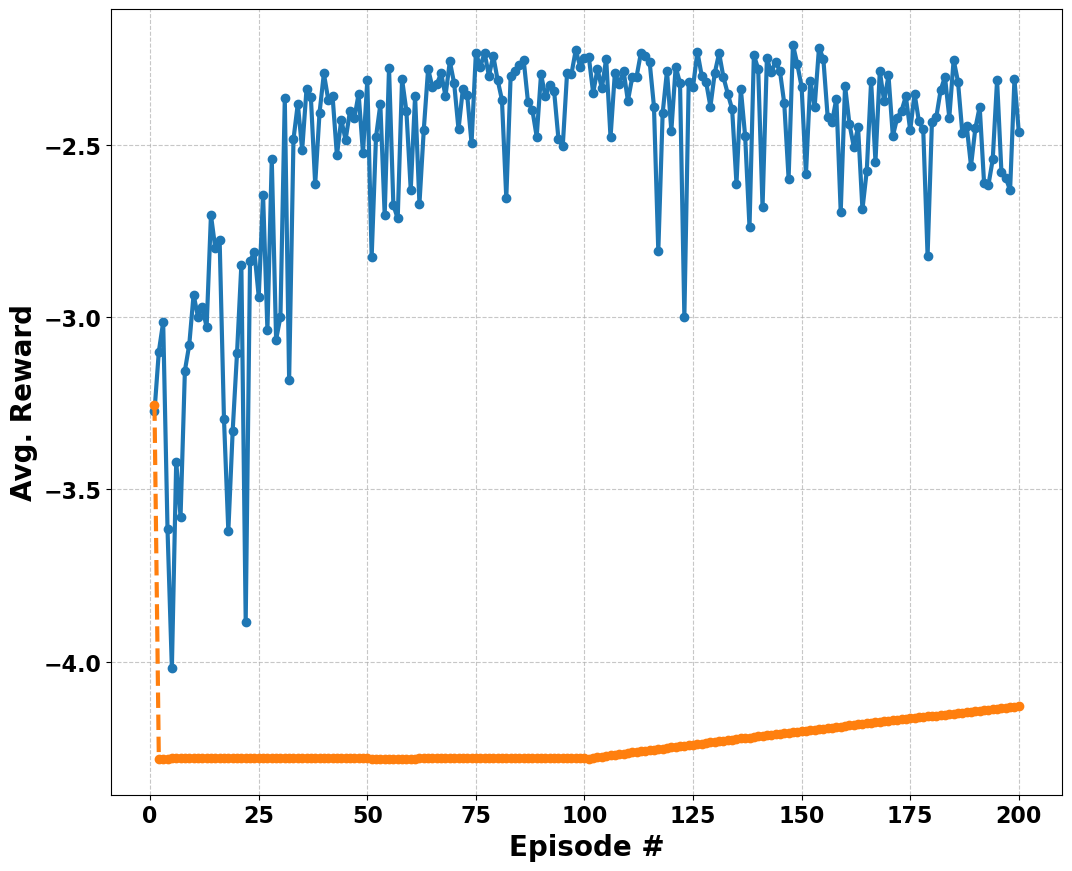

In [37]:
compare_mpc_rl_disturbance(y_system, y_mpc, y_sp, avg_rewards, avg_rewards_mpc, time_in_sub_episodes, delta_t)